In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

env      = gym.make('CartPole-v1')
STATE_DIM  = env.observation_space.shape[0]  
ACTION_DIM = env.action_space.n          
print(f"State dim : {STATE_DIM}")
print(f"Action dim: {ACTION_DIM}")

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        self.actor  = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)
    
    def forward(self, x):
        shared       = self.shared(x)
        action_probs = F.softmax(self.actor(shared), dim=-1)
        state_value  = self.critic(shared)
        return action_probs, state_value
    
    def get_action(self, state):
        state_tensor             = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_probs, state_value = self(state_tensor)
        dist     = torch.distributions.Categorical(action_probs)
        action   = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob, state_value

ppo_net   = ActorCritic(STATE_DIM, ACTION_DIM).to(device)
optimizer = optim.Adam(ppo_net.parameters(), lr=3e-4)

print(f"ActorCritic params: {sum(p.numel() for p in ppo_net.parameters()):,}")

Device: cuda
State dim : 4
Action dim: 2
ActorCritic params: 17,539


In [ ]:
import torch.nn.functional as F

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        
        self.actor  = nn.Linear(128, action_dim)
        
        self.critic = nn.Linear(128, 1)
    
    def forward(self, x):
        shared = self.shared(x)
        
        action_probs = F.softmax(self.actor(shared), dim=-1)
        
        state_value  = self.critic(shared)
        
        return action_probs, state_value
    
    def get_action(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_probs, state_value = self(state_tensor)
        
        dist   = torch.distributions.Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        
        return action.item(), log_prob, state_value


ppo_net   = ActorCritic(STATE_DIM, ACTION_DIM).to(device)
optimizer = optim.Adam(ppo_net.parameters(), lr=3e-4)

print(f"ActorCritic params: {sum(p.numel() for p in ppo_net.parameters()):,}")

state, _ = env.reset()
action, log_prob, value = ppo_net.get_action(state)
print(f"Sample action   : {action}")
print(f"Log probability : {log_prob.item():.4f}")
print(f"State value     : {value.item():.4f}")

ActorCritic params: 17,539
Sample action   : 1
Log probability : -0.6743
State value     : 0.0378


Training PPO (rollout-based)...
Update   20/200 | Avg Reward (last 20 ep): 187.6 | Episodes: 487
Update   40/200 | Avg Reward (last 20 ep): 452.6 | Episodes: 612

Solved at update 59!


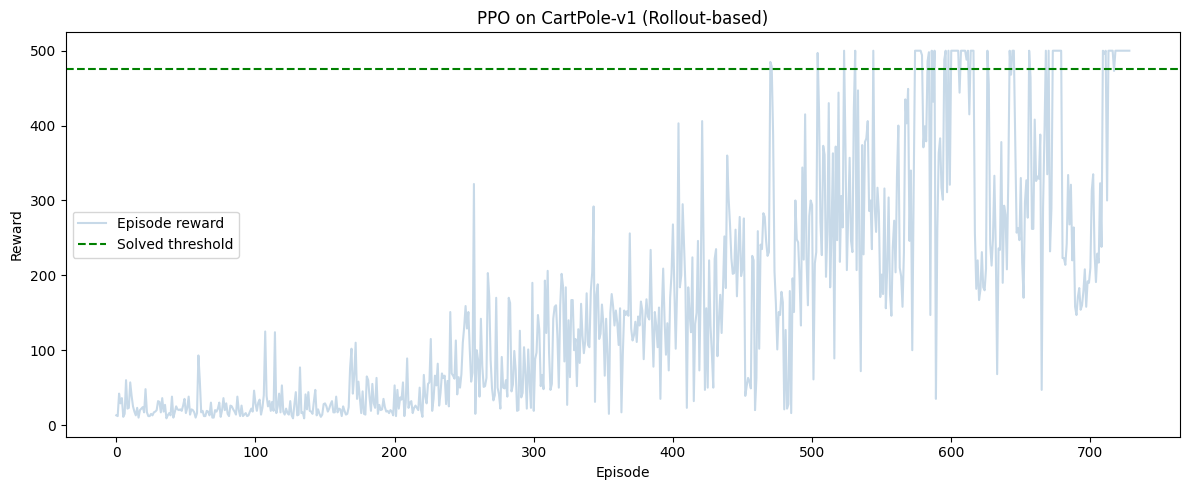

In [ ]:
ppo_net   = ActorCritic(STATE_DIM, ACTION_DIM).to(device)
optimizer = optim.Adam(ppo_net.parameters(), lr=3e-4)

ROLLOUT_STEPS = 2048  
BATCH_SIZE    = 64
K_EPOCHS      = 10
CLIP_EPSILON  = 0.2
GAMMA         = 0.99
LAMBDA        = 0.95
ENTROPY_BETA  = 0.01
N_UPDATES     = 200  

episode_rewards = []
avg_rewards     = []
current_rewards = []

print("Training PPO (rollout-based)...")
print("="*55)

state, _ = env.reset()
ep_reward = 0

for update in range(N_UPDATES):
    rollout_states    = []
    rollout_actions   = []
    rollout_rewards   = []
    rollout_log_probs = []
    rollout_values    = []
    rollout_dones     = []
    
    for step in range(ROLLOUT_STEPS):
        action, log_prob, value = ppo_net.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        rollout_states.append(state)
        rollout_actions.append(action)
        rollout_rewards.append(reward)
        rollout_log_probs.append(log_prob)
        rollout_values.append(value.item())
        rollout_dones.append(done)
        
        state      = next_state
        ep_reward += reward
        
        if done:
            episode_rewards.append(ep_reward)
            current_rewards.append(ep_reward)
            ep_reward  = 0
            state, _   = env.reset()
    
    states_t    = torch.FloatTensor(np.array(rollout_states)).to(device)
    actions_t   = torch.LongTensor(rollout_actions).to(device)
    log_probs_t = torch.stack(rollout_log_probs).squeeze().to(device)
    
    returns, advantages = compute_returns(
        rollout_rewards, rollout_values, rollout_dones, GAMMA, LAMBDA)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    for _ in range(K_EPOCHS):
        indices = torch.randperm(ROLLOUT_STEPS)
        for start in range(0, ROLLOUT_STEPS, BATCH_SIZE):
            idx = indices[start:start + BATCH_SIZE]
            
            batch_states     = states_t[idx]
            batch_actions    = actions_t[idx]
            batch_log_probs  = log_probs_t[idx]
            batch_returns    = returns[idx]
            batch_advantages = advantages[idx]
            
            action_probs, state_values = ppo_net(batch_states)
            dist          = torch.distributions.Categorical(action_probs)
            new_log_probs = dist.log_prob(batch_actions)
            entropy       = dist.entropy().mean()
            
            ratio = torch.exp(new_log_probs - batch_log_probs.detach())
            surr1 = ratio * batch_advantages
            surr2 = torch.clamp(ratio, 1-CLIP_EPSILON, 1+CLIP_EPSILON) * batch_advantages
            
            actor_loss  = -torch.min(surr1, surr2).mean()
            critic_loss = F.mse_loss(state_values.squeeze(), batch_returns)
            loss        = actor_loss + 0.5 * critic_loss - ENTROPY_BETA * entropy
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ppo_net.parameters(), 0.5)
            optimizer.step()
    
    avg = np.mean(current_rewards[-20:]) if current_rewards else 0
    avg_rewards.append(avg)
    
    if (update + 1) % 20 == 0:
        print(f"Update {update+1:4d}/{N_UPDATES} | "
              f"Avg Reward (last 20 ep): {avg:.1f} | "
              f"Episodes: {len(episode_rewards)}")
    
    if avg >= 475:
        print(f"\nSolved at update {update+1}!")
        break

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', label='Episode reward')
plt.axhline(y=475, color='green', linestyle='--', label='Solved threshold')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('PPO on CartPole-v1 (Rollout-based)')
plt.legend()
plt.tight_layout()
plt.show()